In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os
import numpy as np

-----

Data Cleaning

------

In [63]:
day1_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/prices_round_0_day_-1.csv", sep=';')
day1_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [64]:
day1_prices.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [65]:
day1_prices.shape

(20000, 17)

In [66]:
day1_prices.isna().sum()  # see how many missing per column

day                    0
timestamp              0
product                0
bid_price_1            0
bid_volume_1           0
bid_price_2            0
bid_volume_2           0
bid_price_3        19475
bid_volume_3       19475
ask_price_1            0
ask_volume_1           0
ask_price_2            0
ask_volume_2           0
ask_price_3        19482
ask_volume_3       19482
mid_price              0
profit_and_loss        0
dtype: int64

In [67]:
day1_prices.describe()

,day,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
count,20000.0,20000.0000,20000.000000,20000.000000,20000.000000,20000.000000,525.000000,525.000000,20000.000000,20000.000000,20000.000000,20000.000000,518.000000,518.000000,20000.000000,20000.0
mean,-1.0,499950.0000,7481.603250,9.955450,7479.849450,22.178250,6481.009524,21.615238,7495.962500,9.963750,7497.738500,22.179700,6566.333977,21.662162,7488.782875,0.0
std,0.0,288682.3503,2510.607187,3.085213,2510.265922,4.528521,2304.611675,3.919095,2511.991297,3.081901,2512.312824,4.530357,2335.749394,3.941516,2511.299116,0.0
min,-1.0,0.0000,4941.000000,2.000000,4940.000000,5.000000,4942.000000,5.000000,4950.000000,1.000000,4956.000000,5.000000,4957.000000,15.000000,4946.500000,0.0
25%,-1.0,249975.0000,4974.000000,7.000000,4972.000000,20.000000,4964.000000,19.000000,4986.000000,7.000000,4988.000000,20.000000,4979.000000,19.000000,4980.000000,0.0
50%,-1.0,499950.0000,7500.000000,10.000000,7495.500000,22.000000,4981.000000,22.000000,7508.000000,10.000000,7512.500000,22.000000,4996.000000,22.000000,7503.500000,0.0
75%,-1.0,749925.0000,9992.000000,13.000000,9990.000000,25.000000,9990.000000,24.000000,10008.000000,13.000000,10010.000000,25.000000,10010.000000,24.000000,10000.000000,0.0
max,-1.0,999900.0000,10000.000000,15.000000,9992.000000,30.000000,9990.000000,30.000000,10008.000000,15.000000,10010.000000,30.000000,10010.000000,30.000000,10004.000000,0.0


In [68]:
day1_prices_clean = day1_prices.drop(['bid_price_3', 'ask_price_3', 'bid_volume_3', 'ask_volume_3'], axis=1)  
day1_prices_clean.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0


In [69]:
day1_prices_clean.isna().sum()

day                0
timestamp          0
product            0
bid_price_1        0
bid_volume_1       0
bid_price_2        0
bid_volume_2       0
ask_price_1        0
ask_volume_1       0
ask_price_2        0
ask_volume_2       0
mid_price          0
profit_and_loss    0
dtype: int64

In [70]:
day1_trades = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/trades_round_0_day_-1.csv", sep=';')
day1_trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5


In [71]:
day1_trades.shape

(631, 7)

In [72]:
day1_trades.isna().sum()

timestamp      0
buyer        631
seller       631
symbol         0
currency       0
price          0
quantity       0
dtype: int64

In [73]:
day1_trades_clean = day1_trades.drop(['buyer', 'seller'], axis = 1)
day1_trades_clean

,timestamp,symbol,currency,price,quantity
0,3200,EMERALDS,XIRECS,9992.0,8
1,3400,TOMATOES,XIRECS,5009.0,2
2,5000,EMERALDS,XIRECS,9992.0,7
3,7000,TOMATOES,XIRECS,5010.0,4
4,9600,TOMATOES,XIRECS,4999.0,5
...,...,...,...,...,...
626,983800,EMERALDS,XIRECS,10008.0,3
627,985100,TOMATOES,XIRECS,4946.0,2
628,985600,EMERALDS,XIRECS,10008.0,6
629,993000,TOMATOES,XIRECS,4956.0,2


In [74]:
day1_prices_clean['timestamp']

0             0
1             0
2           100
3           100
4           200
          ...  
19995    999700
19996    999800
19997    999800
19998    999900
19999    999900
Name: timestamp, Length: 20000, dtype: int64

In [75]:
day1_trades_clean['timestamp']

0        3200
1        3400
2        5000
3        7000
4        9600
        ...  
626    983800
627    985100
628    985600
629    993000
630    995600
Name: timestamp, Length: 631, dtype: int64

In [76]:
day1_trades_clean.rename(columns={'symbol': 'product'}, inplace=True)

In [77]:
df1_merged = pd.merge(day1_trades_clean, day1_prices_clean, on=['timestamp', 'product'], how='inner')
df1_merged.head()

,timestamp,product,currency,price,quantity,day,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss
0,3200,EMERALDS,XIRECS,9992.0,8,-1,9992,12,9990,22,10008,12,10010,22,10000.0,0.0
1,3400,TOMATOES,XIRECS,5009.0,2,-1,4996,10,4994,17,5009,10,5011,17,5002.5,0.0
2,5000,EMERALDS,XIRECS,9992.0,7,-1,9992,13,9990,28,10000,9,10008,13,9996.0,0.0
3,7000,TOMATOES,XIRECS,5010.0,4,-1,4997,8,4996,19,5010,8,5012,19,5003.5,0.0
4,9600,TOMATOES,XIRECS,4999.0,5,-1,4999,7,4998,20,5013,7,5014,20,5006.0,0.0


In [17]:
df1_merged.describe()

,timestamp,price,quantity,day,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss
count,631.000000,631.000000,631.000000,631.0,631.000000,631.000000,631.000000,631.00000,631.000000,631.000000,631.000000,631.000000,631.000000,631.0
mean,500107.290016,6633.213946,4.106181,-1.0,6626.580032,9.118859,6624.922345,21.03645,6640.370840,9.068146,6642.077655,21.036450,6633.475436,0.0
std,281213.531495,2362.756106,1.627095,0.0,2361.976123,3.011640,2361.634186,4.58745,2363.175374,3.040486,2363.542956,4.482092,2362.575570,0.0
min,3200.000000,4943.000000,2.000000,-1.0,4943.000000,2.000000,4941.000000,5.00000,4953.000000,1.000000,4957.000000,5.000000,4949.000000,0.0
25%,260450.000000,4972.000000,3.000000,-1.0,4965.500000,7.000000,4964.000000,18.00000,4979.000000,7.000000,4980.000000,18.000000,4972.000000,0.0
50%,498300.000000,4990.000000,4.000000,-1.0,4984.000000,9.000000,4982.000000,21.00000,4997.000000,9.000000,4998.000000,21.000000,4990.500000,0.0
75%,748100.000000,9992.000000,5.000000,-1.0,9992.000000,11.000000,9990.000000,24.00000,10008.000000,11.000000,10010.000000,24.000000,10000.000000,0.0
max,995600.000000,10008.000000,8.000000,-1.0,10000.000000,15.000000,9992.000000,30.00000,10008.000000,15.000000,10010.000000,30.000000,10004.000000,0.0


In [18]:
!pip install jsonpickle


In [78]:
day2_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/prices_round_0_day_-2.csv", sep=';')
day2_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0


------

In [79]:
day2_prices.shape

(20000, 17)

In [80]:
day2_prices.isna().sum()  # see how many missing per column

day                    0
timestamp              0
product                0
bid_price_1            0
bid_volume_1           0
bid_price_2            0
bid_volume_2           0
bid_price_3        19475
bid_volume_3       19475
ask_price_1            0
ask_volume_1           0
ask_price_2            0
ask_volume_2           0
ask_price_3        19471
ask_volume_3       19471
mid_price              0
profit_and_loss        0
dtype: int64

In [81]:
day2_prices_clean = day2_prices.drop(['bid_price_3', 'ask_price_3', 'bid_volume_3', 'ask_volume_3'], axis=1)  
day2_prices_clean.head()

day2_prices_clean.isna().sum()

day                0
timestamp          0
product            0
bid_price_1        0
bid_volume_1       0
bid_price_2        0
bid_volume_2       0
ask_price_1        0
ask_volume_1       0
ask_price_2        0
ask_volume_2       0
mid_price          0
profit_and_loss    0
dtype: int64

In [82]:
day2_trades = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Data/Round_0/trades_round_0_day_-2.csv", sep=';')
day2_trades.head()

day2_trades.isna().sum()

day2_trades_clean = day2_trades.drop(['buyer', 'seller'], axis = 1)
day2_trades_clean

,timestamp,symbol,currency,price,quantity
0,900,TOMATOES,XIRECS,5008.0,2
1,1700,TOMATOES,XIRECS,5006.0,3
2,4000,EMERALDS,XIRECS,10008.0,7
3,4100,TOMATOES,XIRECS,5002.0,3
4,5200,EMERALDS,XIRECS,9992.0,5
...,...,...,...,...,...
583,986100,TOMATOES,XIRECS,5002.0,5
584,988600,TOMATOES,XIRECS,5004.0,5
585,989300,TOMATOES,XIRECS,5017.0,2
586,991500,TOMATOES,XIRECS,5017.0,2


------

Understanding how each asset moves

In [83]:
day1_prices_clean.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'ask_price_1', 'ask_volume_1',
       'ask_price_2', 'ask_volume_2', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [84]:
day2_prices_clean.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'ask_price_1', 'ask_volume_1',
       'ask_price_2', 'ask_volume_2', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [85]:
day1_prices_clean

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999700,EMERALDS,9992,12,9990,26,10008,12,10010,26,10000.0,0.0
19996,-1,999800,EMERALDS,9992,13,9990,20,10008,13,10010,20,10000.0,0.0
19997,-1,999800,TOMATOES,4951,6,4949,18,4964,6,4965,18,4957.5,0.0
19998,-1,999900,TOMATOES,4950,10,4949,25,4964,10,4965,25,4957.0,0.0


In [86]:
day1_prices_clean['spread'] = day1_prices_clean['ask_price_1'] - day1_prices_clean['bid_price_1']
day1_prices_clean

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0,14
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0,16
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0,16
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0,13
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999700,EMERALDS,9992,12,9990,26,10008,12,10010,26,10000.0,0.0,16
19996,-1,999800,EMERALDS,9992,13,9990,20,10008,13,10010,20,10000.0,0.0,16
19997,-1,999800,TOMATOES,4951,6,4949,18,4964,6,4965,18,4957.5,0.0,13
19998,-1,999900,TOMATOES,4950,10,4949,25,4964,10,4965,25,4957.0,0.0,14


In [87]:
day2_prices_clean['spread'] = day2_prices_clean['ask_price_1'] - day2_prices_clean['bid_price_1']
day2_prices_clean

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-2,0,EMERALDS,9992,11,9990,25,10008,11,10010,25,10000.0,0.0,16
1,-2,0,TOMATOES,4993,7,4992,17,5007,7,5008,17,5000.0,0.0,14
2,-2,100,TOMATOES,4998,5,4993,7,5007,7,5008,16,5002.5,0.0,9
3,-2,100,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16
4,-2,200,TOMATOES,4994,6,4993,20,5008,6,5009,20,5001.0,0.0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-2,999700,EMERALDS,9992,10,9990,22,10008,10,10010,22,10000.0,0.0,16
19996,-2,999800,EMERALDS,9992,14,9990,25,10008,14,10010,25,10000.0,0.0,16
19997,-2,999800,TOMATOES,5000,7,4999,24,5014,7,5015,24,5007.0,0.0,14
19998,-2,999900,TOMATOES,5000,7,4998,20,5013,7,5015,20,5006.5,0.0,13


In [29]:
day1_prices_clean.groupby('product').agg(['mean', 'std', 'min', 'max']).T

product                    EMERALDS       TOMATOES
day             mean      -1.000000      -1.000000
                std        0.000000       0.000000
                min       -1.000000      -1.000000
                max       -1.000000      -1.000000
timestamp       mean  499950.000000  499950.000000
                std   288689.567991  288689.567991
                min        0.000000       0.000000
                max   999900.000000  999900.000000
bid_price_1     mean    9992.126400    4971.080100
                std        0.997659      14.581761
                min     9992.000000    4941.000000
                max    10000.000000    5008.000000
bid_volume_1    mean      12.457000       7.453900
                std        1.814519       1.796886
                min        5.000000       2.000000
                max       15.000000      12.000000
bid_price_2     mean    9990.031600    4969.667300
                std        0.249415      14.524411
                min     9990.000000    4940.000000
                max     9992.000000    5001.000000
bid_volume_2    mean      24.781500      19.575000
                std        3.515849       3.885960
                min       10.000000       5.000000
                max       30.000000      25.000000
ask_price_1     mean   10007.869600    4984.055400
                std        1.013064      14.627875
                min    10000.000000    4950.000000
                max    10008.000000    5016.000000
ask_volume_1    mean      12.462700       7.464800
                std        1.808075       1.799246
                min        5.000000       1.000000
                max       15.000000      12.000000
ask_price_2     mean   10009.967400    4985.509600
                std        0.253266      14.565237
                min    10008.000000    4956.000000
                max    10010.000000    5017.000000
ask_volume_2    mean      24.767300      19.592100
                std        3.543925       3.885644
                min       10.000000       5.000000
                max       30.000000      25.000000
mid_price       mean    9999.998000    4977.567750
                std        0.716692      14.578497
                min     9996.000000    4946.500000
                max    10004.000000    5011.000000
profit_and_loss mean       0.000000       0.000000
                std        0.000000       0.000000
                min        0.000000       0.000000
                max        0.000000       0.000000
spread          mean      15.743200      12.975300
                std        1.410196       1.753453
                min        8.000000       5.000000
                max       16.000000      14.000000

----

In [30]:
day2_prices_clean.groupby('product').agg(['mean', 'std', 'min', 'max']).T

product                    EMERALDS       TOMATOES
day             mean      -2.000000      -2.000000
                std        0.000000       0.000000
                min       -2.000000      -2.000000
                max       -2.000000      -2.000000
timestamp       mean  499950.000000  499950.000000
                std   288689.567991  288689.567991
                min        0.000000       0.000000
                max   999900.000000  999900.000000
bid_price_1     mean    9992.130400    5001.415900
                std        1.013064      10.299754
                min     9992.000000    4982.000000
                max    10000.000000    5032.000000
bid_volume_1    mean      12.457100       7.428100
                std        1.825786       1.787666
                min        5.000000       2.000000
                max       15.000000      12.000000
bid_price_2     mean    9990.032600    5000.006400
                std        0.253266      10.248818
                min     9990.000000    4981.000000
                max     9992.000000    5027.000000
bid_volume_2    mean      24.836600      19.582300
                std        3.533829       3.899044
                min       10.000000       3.000000
                max       30.000000      25.000000
ask_price_1     mean   10007.864000    5014.481100
                std        1.034220      10.352283
                min    10000.000000    4991.000000
                max    10008.000000    5042.000000
ask_volume_1    mean      12.456900       7.425300
                std        1.822436       1.786824
                min        5.000000       2.000000
                max       15.000000      12.000000
ask_price_2     mean   10009.966000    5015.935900
                std        0.258555      10.276583
                min    10008.000000    4997.000000
                max    10010.000000    5043.000000
ask_volume_2    mean      24.832000      19.583500
                std        3.552723       3.881718
                min       10.000000       5.000000
                max       30.000000      25.000000
mid_price       mean    9999.997200    5007.948500
                std        0.729963      10.288714
                min     9996.000000    4988.000000
                max    10004.000000    5036.000000
profit_and_loss mean       0.000000       0.000000
                std        0.000000       0.000000
                min        0.000000       0.000000
                max        0.000000       0.000000
spread          mean      15.733600      13.065200
                std        1.435422       1.754667
                min        8.000000       5.000000
                max       16.000000      14.000000

In [92]:
file_path = "/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day1_prices.csv"

day1_prices_clean.to_csv(file_path, index=False)

In [93]:
file_path = "/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day2_prices.csv"

day2_prices_clean.to_csv(file_path, index=False)

In [94]:
file_path = "/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day1_trades.csv"

day1_trades_clean.to_csv(file_path, index=False)

In [95]:
file_path = "/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day2_trades.csv"

day2_trades_clean.to_csv(file_path, index=False)

-------

1) Prices:

EMERALDS:

mid_price mean is around 10,000, std around 0.7 - very stable / stationary

min/max is tight 

Strat:

Almost no price drift. No need of sophisticated signals cause execution matters more than predicting price moves.

TOMATOES:

mid_price mean is around 4977.5, std around 14.6 so high volatility compared to EMERALDS

min/max spread is  noisy and drifting

Strat:
Price is comparatively much harder to predict. Any strategy should be adaptive, using EMA or rolling mean to track fair value. Also, volatility scaling could help

Spread observation:

EMERALDS: ≈ 15 ticks (10007.87 – 9992.13)

TOMATOES: ≈ 6 ticks (4984.05 – 4977.57)

EMERALDS has wider fixed spread but very little movement; TOMATOES has tighter spread but noisy

------

Analyzing volumes

In [31]:
day1_prices_clean['imbalance'] = (day1_prices_clean['bid_volume_1'] - day1_prices_clean['ask_volume_1']) / (day1_prices_clean['bid_volume_1'] + day1_prices_clean['ask_volume_1'])

In [32]:
day1_prices_clean.groupby('product')['imbalance'].describe()

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
EMERALDS,10000.0,-0.000281,0.049652,-0.500000,0.0,0.0,0.0,0.50
TOMATOES,10000.0,-0.000707,0.085389,-0.666667,0.0,0.0,0.0,0.75


In [33]:
# Micro price 

day1_prices_clean['micro_price'] = (day1_prices_clean['bid_price_1'] * day1_prices_clean['ask_volume_1'] + day1_prices_clean['ask_price_1'] * day1_prices_clean['bid_volume_1']) / (day1_prices_clean['bid_volume_1'] + day1_prices_clean['ask_volume_1'])

In [34]:
day1_prices_clean['micro_mid_diff'] = day1_prices_clean['micro_price'] - day1_prices_clean['mid_price']
day1_prices_clean.groupby('product')['micro_mid_diff'].apply(lambda x: (x > 0).sum())

product
EMERALDS    158
TOMATOES    320
Name: micro_mid_diff, dtype: int64

In [35]:
day1_prices_clean.groupby('product').count()

,day,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread,imbalance,micro_price,micro_mid_diff
product,,,,,,,,,,,,,,,,
EMERALDS,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
TOMATOES,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000


-------

Deeper Analysis of both Datasets

-----

In [36]:
day1_prices_clean[day1_prices_clean['product'] == 'EMERALDS']['spread'].describe()

count    10000.000000
mean        15.743200
std          1.410196
min          8.000000
25%         16.000000
50%         16.000000
75%         16.000000
max         16.000000
Name: spread, dtype: float64

----

1. Spread Distribution

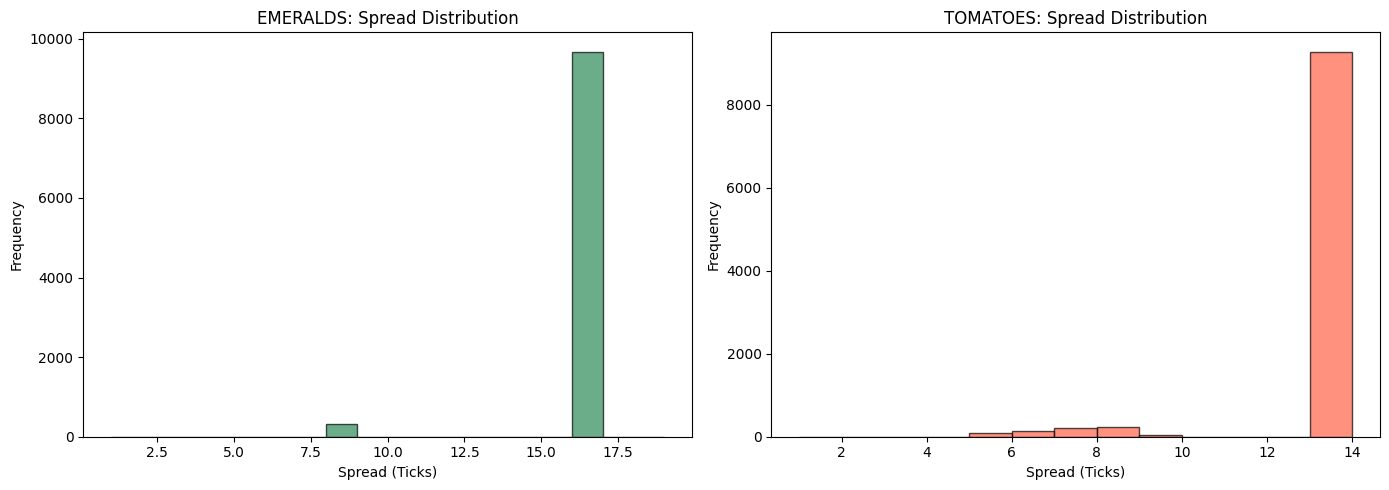

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Plot Emeralds
emeralds_spread = day1_prices_clean[day1_prices_clean['product'] == 'EMERALDS']['spread']
ax1.hist(emeralds_spread, bins=range(1, 20), color='seagreen', edgecolor='black', alpha=0.7)
ax1.set_title('EMERALDS: Spread Distribution')
ax1.set_xlabel('Spread (Ticks)')
ax1.set_ylabel('Frequency')

# Plot Tomatoes
tomatoes_spread = day1_prices_clean[day1_prices_clean['product'] == 'TOMATOES']['spread']
ax2.hist(tomatoes_spread, bins=range(1, 15), color='tomato', edgecolor='black', alpha=0.7)
ax2.set_title('TOMATOES: Spread Distribution')
ax2.set_xlabel('Spread (Ticks)')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

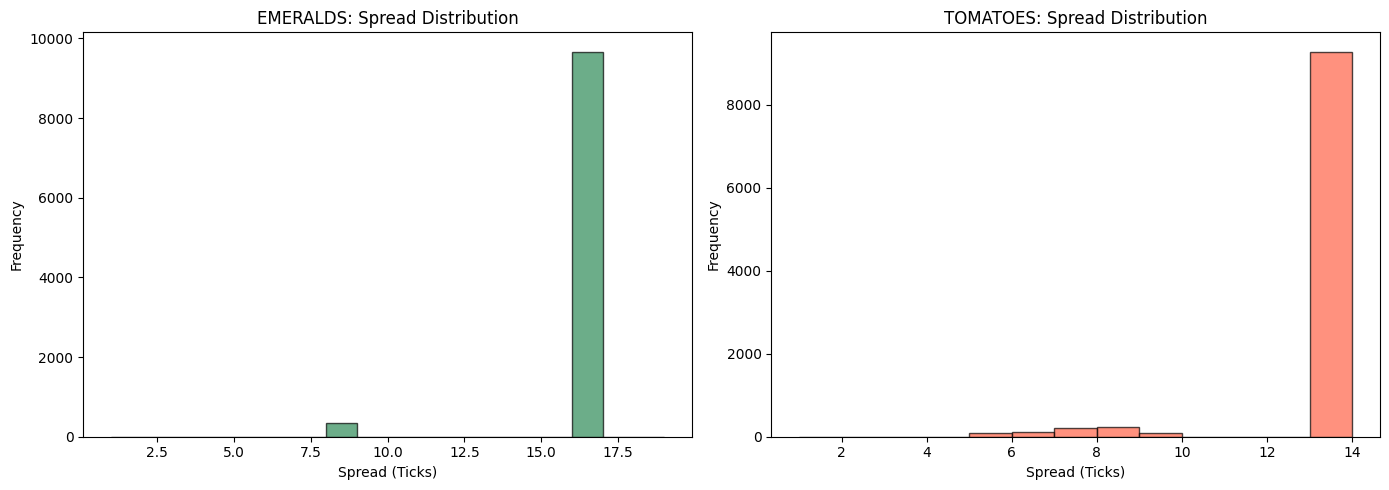

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Plot Emeralds
emeralds_spread = day2_prices_clean[day2_prices_clean['product'] == 'EMERALDS']['spread']
ax1.hist(emeralds_spread, bins=range(1, 20), color='seagreen', edgecolor='black', alpha=0.7)
ax1.set_title('EMERALDS: Spread Distribution')
ax1.set_xlabel('Spread (Ticks)')
ax1.set_ylabel('Frequency')

# Plot Tomatoes
tomatoes_spread = day2_prices_clean[day2_prices_clean['product'] == 'TOMATOES']['spread']
ax2.hist(tomatoes_spread, bins=range(1, 15), color='tomato', edgecolor='black', alpha=0.7)
ax2.set_title('TOMATOES: Spread Distribution')
ax2.set_xlabel('Spread (Ticks)')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [39]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(group):
    
    min_s = group['spread'].min()
    pct_min = (group['spread'] == min_s).mean() * 100
    return pd.Series({
        'Min Spread': min_s,
        '% Time at Min': f"{pct_min:.2f}%",
        'Max Spread': group['spread'].max(),
        'Avg Spread': group['spread'].mean()
    })

spread_analysis = day1_prices_clean.groupby('product').apply(get_spread_stats)
spread_analysis

/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/4042929830.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spread_analysis = day1_prices_clean.groupby('product').apply(get_spread_stats)


,Min Spread,% Time at Min,Max Spread,Avg Spread
product,,,,
EMERALDS,8,3.21%,16,15.7432
TOMATOES,5,0.91%,14,12.9753


In [40]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(group):
    
    max_s = group['spread'].max()
    pct_min = (group['spread'] == max_s).mean() * 100
    return pd.Series({
        'Max Spread': max_s,
        '% Time at Max': f"{pct_min:.2f}%",
        'Min Spread': group['spread'].min(),
        'Avg Spread': group['spread'].mean()
    })

spread_analysis = day1_prices_clean.groupby('product').apply(get_spread_stats)
spread_analysis

/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/3912649256.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spread_analysis = day1_prices_clean.groupby('product').apply(get_spread_stats)


,Max Spread,% Time at Max,Min Spread,Avg Spread
product,,,,
EMERALDS,16,96.79%,8,15.7432
TOMATOES,14,40.64%,5,12.9753


In [41]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(group):
    
    max_s = group['spread'].max()
    pct_min = (group['spread'] == max_s).mean() * 100
    return pd.Series({
        'Max Spread': max_s,
        '% Time at Max': f"{pct_min:.2f}%",
        'Min Spread': group['spread'].min(),
        'Avg Spread': group['spread'].mean()
    })

spread_analysis = day2_prices_clean.groupby('product').apply(get_spread_stats)
spread_analysis

/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/66872367.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spread_analysis = day2_prices_clean.groupby('product').apply(get_spread_stats)


,Max Spread,% Time at Max,Min Spread,Avg Spread
product,,,,
EMERALDS,16,96.67%,8,15.7336
TOMATOES,14,48.90%,5,13.0652


--------

2. Spread Movement with Volatility

In [42]:
day1_prices_clean['volatility'] = day1_prices_clean.groupby('product')['mid_price'].transform(lambda x: x.rolling(20).std())

# Correlation: 1.0 means they move perfectly together
vol_corr = day1_prices_clean.groupby('product').apply(lambda x: x['spread'].corr(x['volatility']))
print("\nCorrelation (Spread vs Volatility):")
print(vol_corr)


Correlation (Spread vs Volatility):
product
EMERALDS   -0.217000
TOMATOES   -0.127387
dtype: float64


/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/1858900639.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vol_corr = day1_prices_clean.groupby('product').apply(lambda x: x['spread'].corr(x['volatility']))


In [43]:
day2_prices_clean['volatility'] = day2_prices_clean.groupby('product')['mid_price'].transform(lambda x: x.rolling(20).std())

# Correlation: 1.0 means they move perfectly together
vol_corr = day2_prices_clean.groupby('product').apply(lambda x: x['spread'].corr(x['volatility']))
print("\nCorrelation (Spread vs Volatility):")
print(vol_corr)


Correlation (Spread vs Volatility):
product
EMERALDS   -0.216263
TOMATOES   -0.137138
dtype: float64


/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/35952734.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vol_corr = day2_prices_clean.groupby('product').apply(lambda x: x['spread'].corr(x['volatility']))


----

3. Stats of Returns

In [44]:
day1_prices_clean['returns'] = day1_prices_clean.groupby('product')['mid_price'].diff()

return_stats = day1_prices_clean.groupby('product')['returns'].agg(['mean', 'std', 'skew'])
print("Return Statistics")
return_stats

Return Statistics


,mean,std,skew
product,,,
EMERALDS,0.0000,0.999300,-0.076992
TOMATOES,-0.0049,1.337155,0.001666


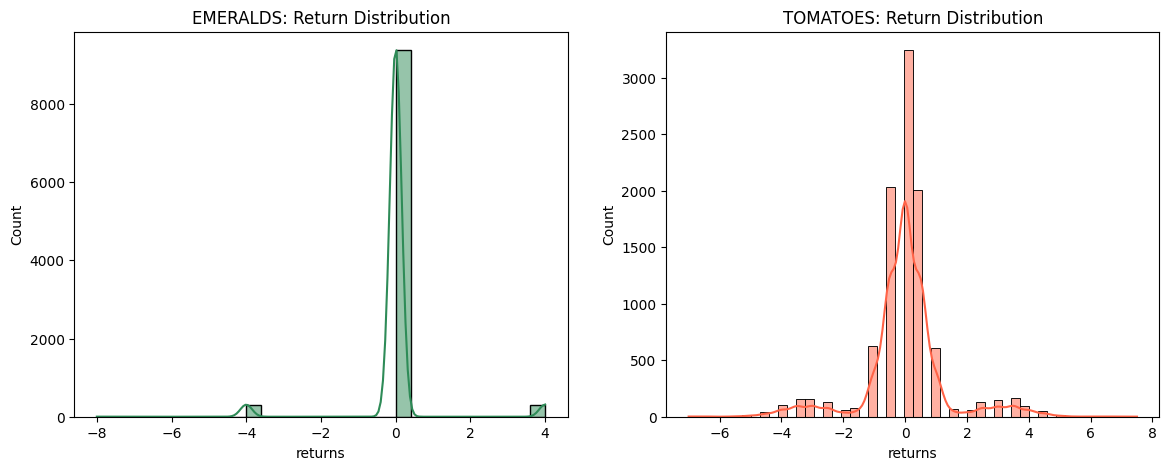

In [45]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Emeralds: Expect a very tight spike at 0
sns.histplot(day1_prices_clean[day1_prices_clean['product']=='EMERALDS']['returns'].dropna(), 
             ax=ax1, kde=True, color='seagreen', bins=30)
ax1.set_title('EMERALDS: Return Distribution')

# Tomatoes: Expect a wider bell curve with more "outliers"
sns.histplot(day1_prices_clean[day1_prices_clean['product']=='TOMATOES']['returns'].dropna(), 
             ax=ax2, kde=True, color='tomato', bins=50)
ax2.set_title('TOMATOES: Return Distribution')

plt.show()

In [46]:
day2_prices_clean['returns'] = day2_prices_clean.groupby('product')['mid_price'].diff()

return_stats = day2_prices_clean.groupby('product')['returns'].agg(['mean', 'std', 'skew'])
print("Return Statistics")
return_stats

Return Statistics


,mean,std,skew
product,,,
EMERALDS,0.00000,1.027721,0.070780
TOMATOES,0.00065,1.345023,-0.041654


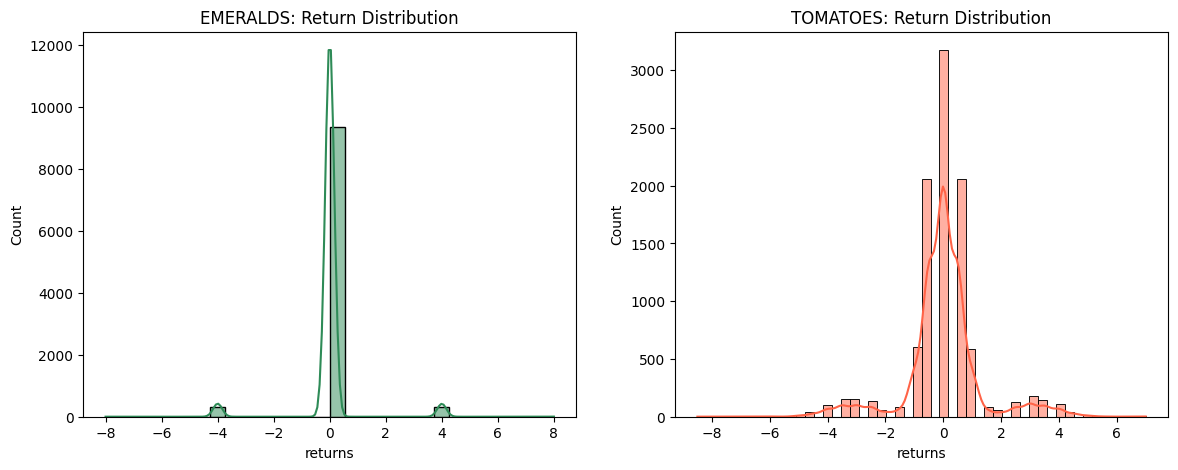

In [47]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Emeralds: Expect a very tight spike at 0
sns.histplot(day2_prices_clean[day2_prices_clean['product']=='EMERALDS']['returns'].dropna(), 
             ax=ax1, kde=True, color='seagreen', bins=30)
ax1.set_title('EMERALDS: Return Distribution')

# Tomatoes: Expect a wider bell curve with more "outliers"
sns.histplot(day2_prices_clean[day2_prices_clean['product']=='TOMATOES']['returns'].dropna(), 
             ax=ax2, kde=True, color='tomato', bins=50)
ax2.set_title('TOMATOES: Return Distribution')

plt.show()

------

4. Autocorrelation of returns

In [48]:
autocorr = day1_prices_clean.groupby('product')['returns'].apply(lambda x: x.autocorr(lag=1))
autocorr

product
EMERALDS   -0.490385
TOMATOES   -0.412480
Name: returns, dtype: float64

In [49]:
autocorr = day2_prices_clean.groupby('product')['returns'].apply(lambda x: x.autocorr(lag=1))
autocorr

product
EMERALDS   -0.484848
TOMATOES   -0.428003
Name: returns, dtype: float64

-------

5. Rolling Volatility Regimes for returns

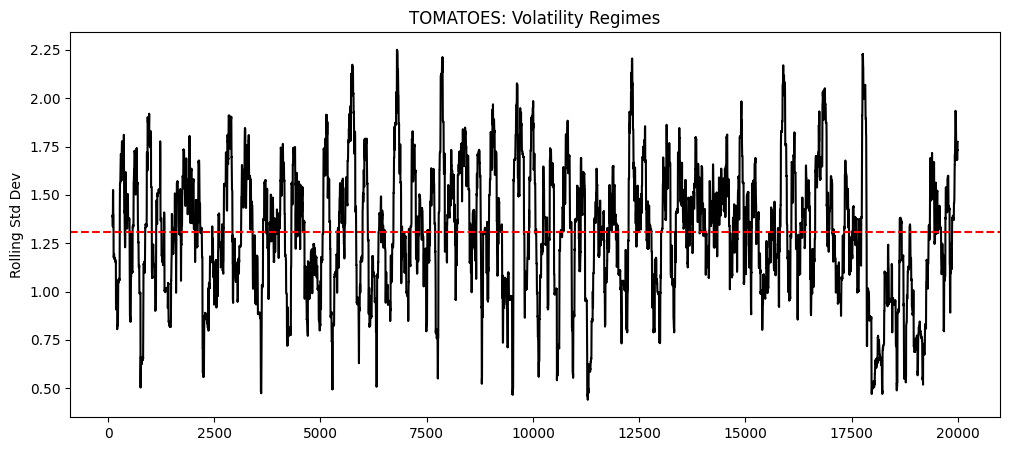

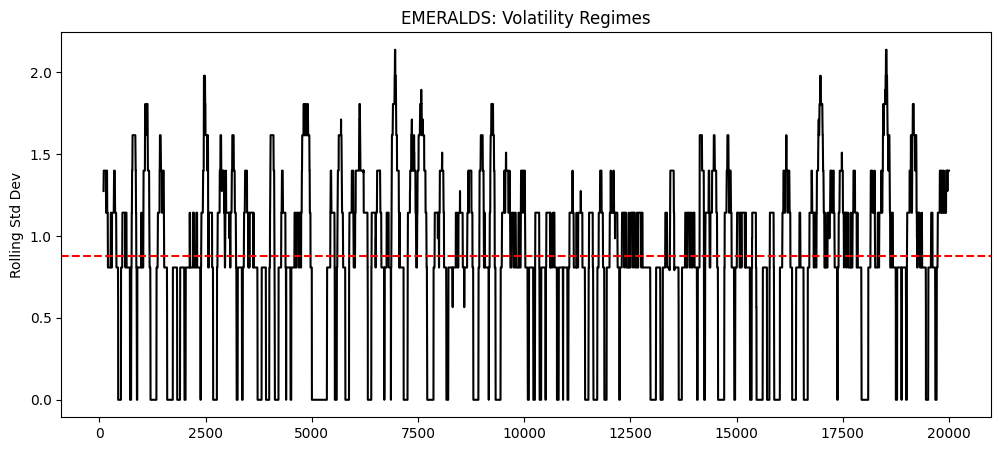

In [50]:
# Calculate rolling 50-period volatility
day1_prices_clean['rolling_vol'] = day1_prices_clean.groupby('product')['returns'].transform(
    lambda x: x.rolling(window=50).std()
)

# Plotting the regimes for Tomatoes
tomatoes_data = day1_prices_clean[day1_prices_clean['product'] == 'TOMATOES']
plt.figure(figsize=(12, 5))
plt.plot(tomatoes_data.index, tomatoes_data['rolling_vol'], color='black')
plt.axhline(tomatoes_data['rolling_vol'].mean(), color='red', linestyle='--', label='Avg Vol')
plt.title('TOMATOES: Volatility Regimes')
plt.ylabel('Rolling Std Dev')
plt.show()

emeralds_data = day1_prices_clean[day1_prices_clean['product'] == 'EMERALDS']
plt.figure(figsize=(12, 5))
plt.plot(emeralds_data.index, emeralds_data['rolling_vol'], color='black')
plt.axhline(emeralds_data['rolling_vol'].mean(), color='red', linestyle='--', label='Avg Vol')
plt.title('EMERALDS: Volatility Regimes')
plt.ylabel('Rolling Std Dev')
plt.show()

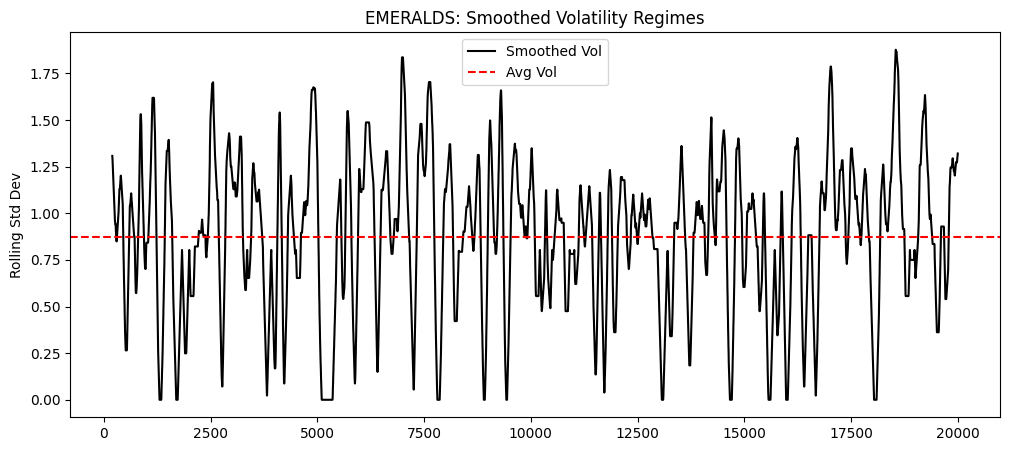

In [51]:
# Smooth the rolling volatility (per product)
day1_prices_clean['smooth_vol'] = day1_prices_clean.groupby('product')['rolling_vol'].transform(
    lambda x: x.rolling(window=50).mean()
)

emeralds_data = day1_prices_clean[day1_prices_clean['product'] == 'EMERALDS']

plt.figure(figsize=(12, 5))
plt.plot(emeralds_data.index, emeralds_data['smooth_vol'], color='black', label='Smoothed Vol')
plt.axhline(emeralds_data['smooth_vol'].mean(), color='red', linestyle='--', label='Avg Vol')
plt.title('EMERALDS: Smoothed Volatility Regimes')
plt.ylabel('Rolling Std Dev')
plt.legend()
plt.show()

In [52]:
day1_prices_clean.index.duplicated().sum()

np.int64(0)

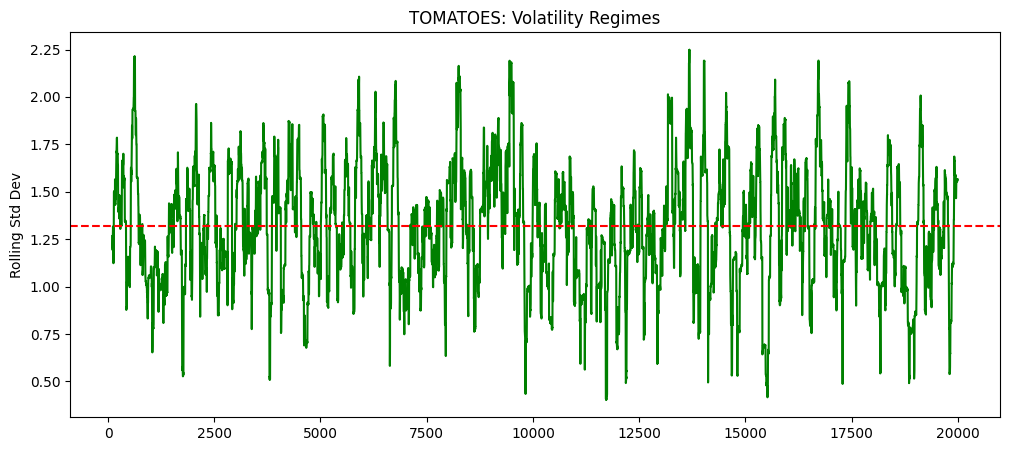

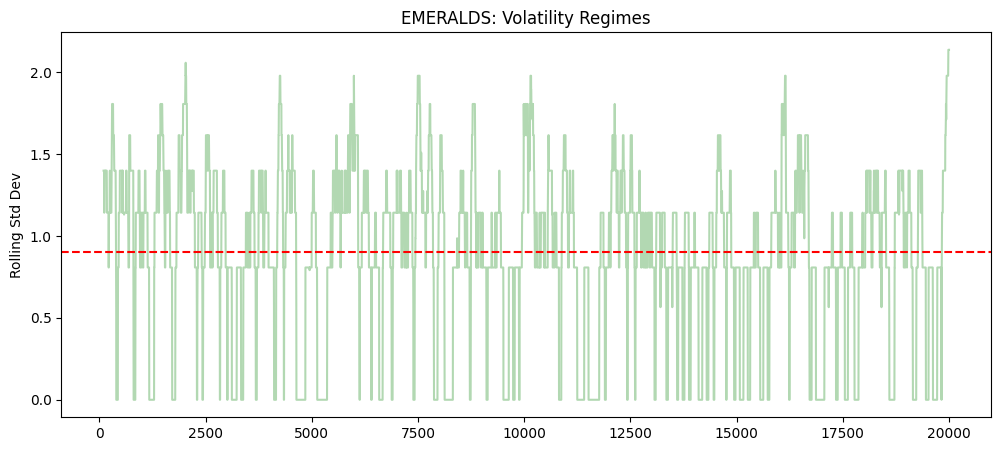

In [53]:
# Calculate rolling 50-period volatility
day2_prices_clean['rolling_vol'] = day2_prices_clean.groupby('product')['returns'].transform(
    lambda x: x.rolling(window=50).std()
)

# Plotting the regimes for Tomatoes
tomatoes_data = day2_prices_clean[day2_prices_clean['product'] == 'TOMATOES']
plt.figure(figsize=(12, 5))
plt.plot(tomatoes_data.index, tomatoes_data['rolling_vol'], color='green')
plt.axhline(tomatoes_data['rolling_vol'].mean(), color='red', linestyle='--', label='Avg Vol')
plt.title('TOMATOES: Volatility Regimes')
plt.ylabel('Rolling Std Dev')
plt.show()

emeralds_data = day2_prices_clean[day2_prices_clean['product'] == 'EMERALDS']
plt.figure(figsize=(12, 5))
plt.plot(emeralds_data.index, emeralds_data['rolling_vol'], color='green', alpha = 0.3)
plt.axhline(emeralds_data['rolling_vol'].mean(), color='red', linestyle='--', label='Avg Vol')
plt.title('EMERALDS: Volatility Regimes')
plt.ylabel('Rolling Std Dev')
plt.show()

-------

6. Fair Value Quality Test

In [56]:
# EMA of mid price 

day1_prices_clean['ema_mid_price'] = day1_prices_clean.groupby('product')['mid_price'].transform(lambda x:x.ewm(span=20, adjust=False).mean())

# Wall mid

day1_prices_clean['wall_mid_price'] = (day1_prices_clean['bid_price_1']*day1_prices_clean['ask_volume_1'] + day1_prices_clean['ask_price_1']*day1_prices_clean['bid_volume_1']) / (day1_prices_clean['bid_volume_1'] + day1_prices_clean['ask_volume_1'])

quality_test = pd.DataFrame({
    'Mid Price Var': day1_prices_clean.groupby('product')['mid_price'].apply(lambda x: x.diff().var()),
    'EMA Mid Var': day1_prices_clean.groupby('product')['ema_mid_price'].apply(lambda x: x.diff().var()),
    'Wall Mid Var': day1_prices_clean.groupby('product')['wall_mid_price'].apply(lambda x: x.diff().var())
})

quality_test

,Mid Price Var,EMA Mid Var,Wall Mid Var
product,,,
EMERALDS,0.998600,0.004881,0.577861
TOMATOES,1.787984,0.020324,1.415682


----

EMERALDS - enough analysis here, pretty clear what to do. TOMATOES is more important

In [ ]:
#Analyzing TOMATOES

tomatoes = day1_prices_clean[day1_prices_clean['product'] == 'TOMATOES']

7. Deviation Analysis

In [58]:
# zscore

window = 50 # Adjust based on how fast you want the bot to react
tomatoes['fair_value'] = tomatoes['mid_price'].ewm(span=window).mean()
tomatoes['rolling_std'] = tomatoes['mid_price'].rolling(window=window).std()

# 2. Calculate Z-Score
tomatoes['z_score'] = (tomatoes['mid_price'] - tomatoes['fair_value']) / tomatoes['rolling_std']

# 3. Analyze Frequency of Deviations
# How often are we beyond 1, 1.5, or 2 sigmas?
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    freq = (tomatoes['z_score'].abs() > threshold).mean() * 100
    print(f"Time spent beyond {threshold} sigma: {freq:.2f}%")

Time spent beyond 1.0 sigma: 40.04%
Time spent beyond 1.5 sigma: 17.69%
Time spent beyond 2.0 sigma: 6.50%
Time spent beyond 2.5 sigma: 2.74%
Time spent beyond 3.0 sigma: 1.29%


/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/3905019577.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomatoes['fair_value'] = tomatoes['mid_price'].ewm(span=window).mean()
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/3905019577.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomatoes['rolling_std'] = tomatoes['mid_price'].rolling(window=window).std()
/var/folders/gx/p5qhhh8s7rg2_ywh443qwth80000gn/T/ipykernel_73214/3905019577.py:8: SettingWithCopyWarning: 
A